In [323]:
# import libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)



In [324]:
#  load the dataset

df = pd.read_csv("./bank-additional/bank-additional-full.csv",sep=";")



In [325]:
# df.to_csv("bank-additional-full-updated.csv")


In [326]:
#  basic info of data 

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [327]:
df.shape

(41188, 21)

In [328]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [329]:
# categorical data summary
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [330]:
# check missinng values 
print(df.isnull().sum())
print()
(df == "unknown").sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64



age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [331]:
# we found "unknown" value in dataset - lets replace with mode

error_col = ['job', 'marital', 'education', 'default', 'housing', 'loan']

for col in error_col:
    df.replace("unknown", np.nan,inplace=True)


# Note : first i had to find outliers then replace with mode()
# but thwere is no outliers in error column


In [332]:
df.isnull().sum()
# df[df == 'unknown'].sum()
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [333]:
for col in error_col:
    df[col].fillna(df[col].mode()[0],inplace=True)


In [334]:
# check unique values
# print(df['day_of_week'].unique())

# print(df['month'].unique()) # there is no jan feb

for col in df.select_dtypes(include='object'):
    print(col," : ",df[col].unique().tolist())

job  :  ['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'entrepreneur', 'student']
marital  :  ['married', 'single', 'divorced']
education  :  ['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'university.degree', 'illiterate']
default  :  ['no', 'yes']
housing  :  ['no', 'yes']
loan  :  ['no', 'yes']
contact  :  ['telephone', 'cellular']
month  :  ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
day_of_week  :  ['mon', 'tue', 'wed', 'thu', 'fri']
poutcome  :  ['nonexistent', 'failure', 'success']
y  :  ['no', 'yes']


In [335]:
# duration was removed to avoid data leakage,
# as it is only known after the call ends. 
# Including it would make the model unrealistically accurate 
# but useless for real-world prediction.

df = df.drop('duration', axis = 1)


In [336]:
df.columns = df.columns.str.strip().str.lower().str.replace('.','_')

        

In [337]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
10,41,blue-collar,married,university.degree,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
11,25,services,single,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
16,35,blue-collar,married,basic.6y,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
31,59,technician,married,university.degree,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
104,52,admin.,divorced,university.degree,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39985,27,admin.,single,high.school,no,no,no,cellular,jun,tue,2,999,0,nonexistent,-1.7,94.055,-39.8,0.761,4991.6,yes
40401,31,student,single,university.degree,no,yes,no,cellular,aug,thu,2,999,0,nonexistent,-1.7,94.027,-38.3,0.904,4991.6,yes
40404,41,entrepreneur,married,university.degree,no,yes,no,cellular,aug,thu,1,999,0,nonexistent,-1.7,94.027,-38.3,0.904,4991.6,yes
40806,35,technician,married,professional.course,no,yes,no,cellular,sep,thu,1,999,2,failure,-1.1,94.199,-37.5,0.878,4963.6,no


In [338]:
df.drop_duplicates(inplace=True)

In [339]:
df.columns # ensures target variable is y

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx',
       'euribor3m', 'nr_employed', 'y'],
      dtype='object')

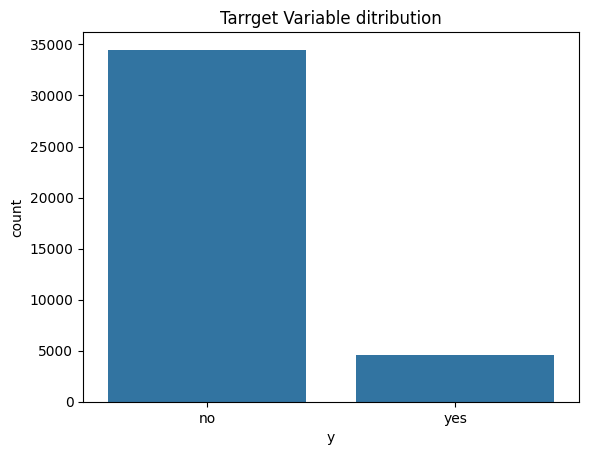

y
no     88.241767
yes    11.758233
Name: proportion, dtype: float64

In [340]:
sns.countplot(x='y',data=df)
plt.title("Tarrget Variable ditribution")
plt.show()

df['y'].value_counts(normalize=True) * 100

# Univariate Analysis

In [341]:


# numerical columns
num_col = df.select_dtypes(include=['int64','float64']).columns
num_col

Index(['age', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed'],
      dtype='object')

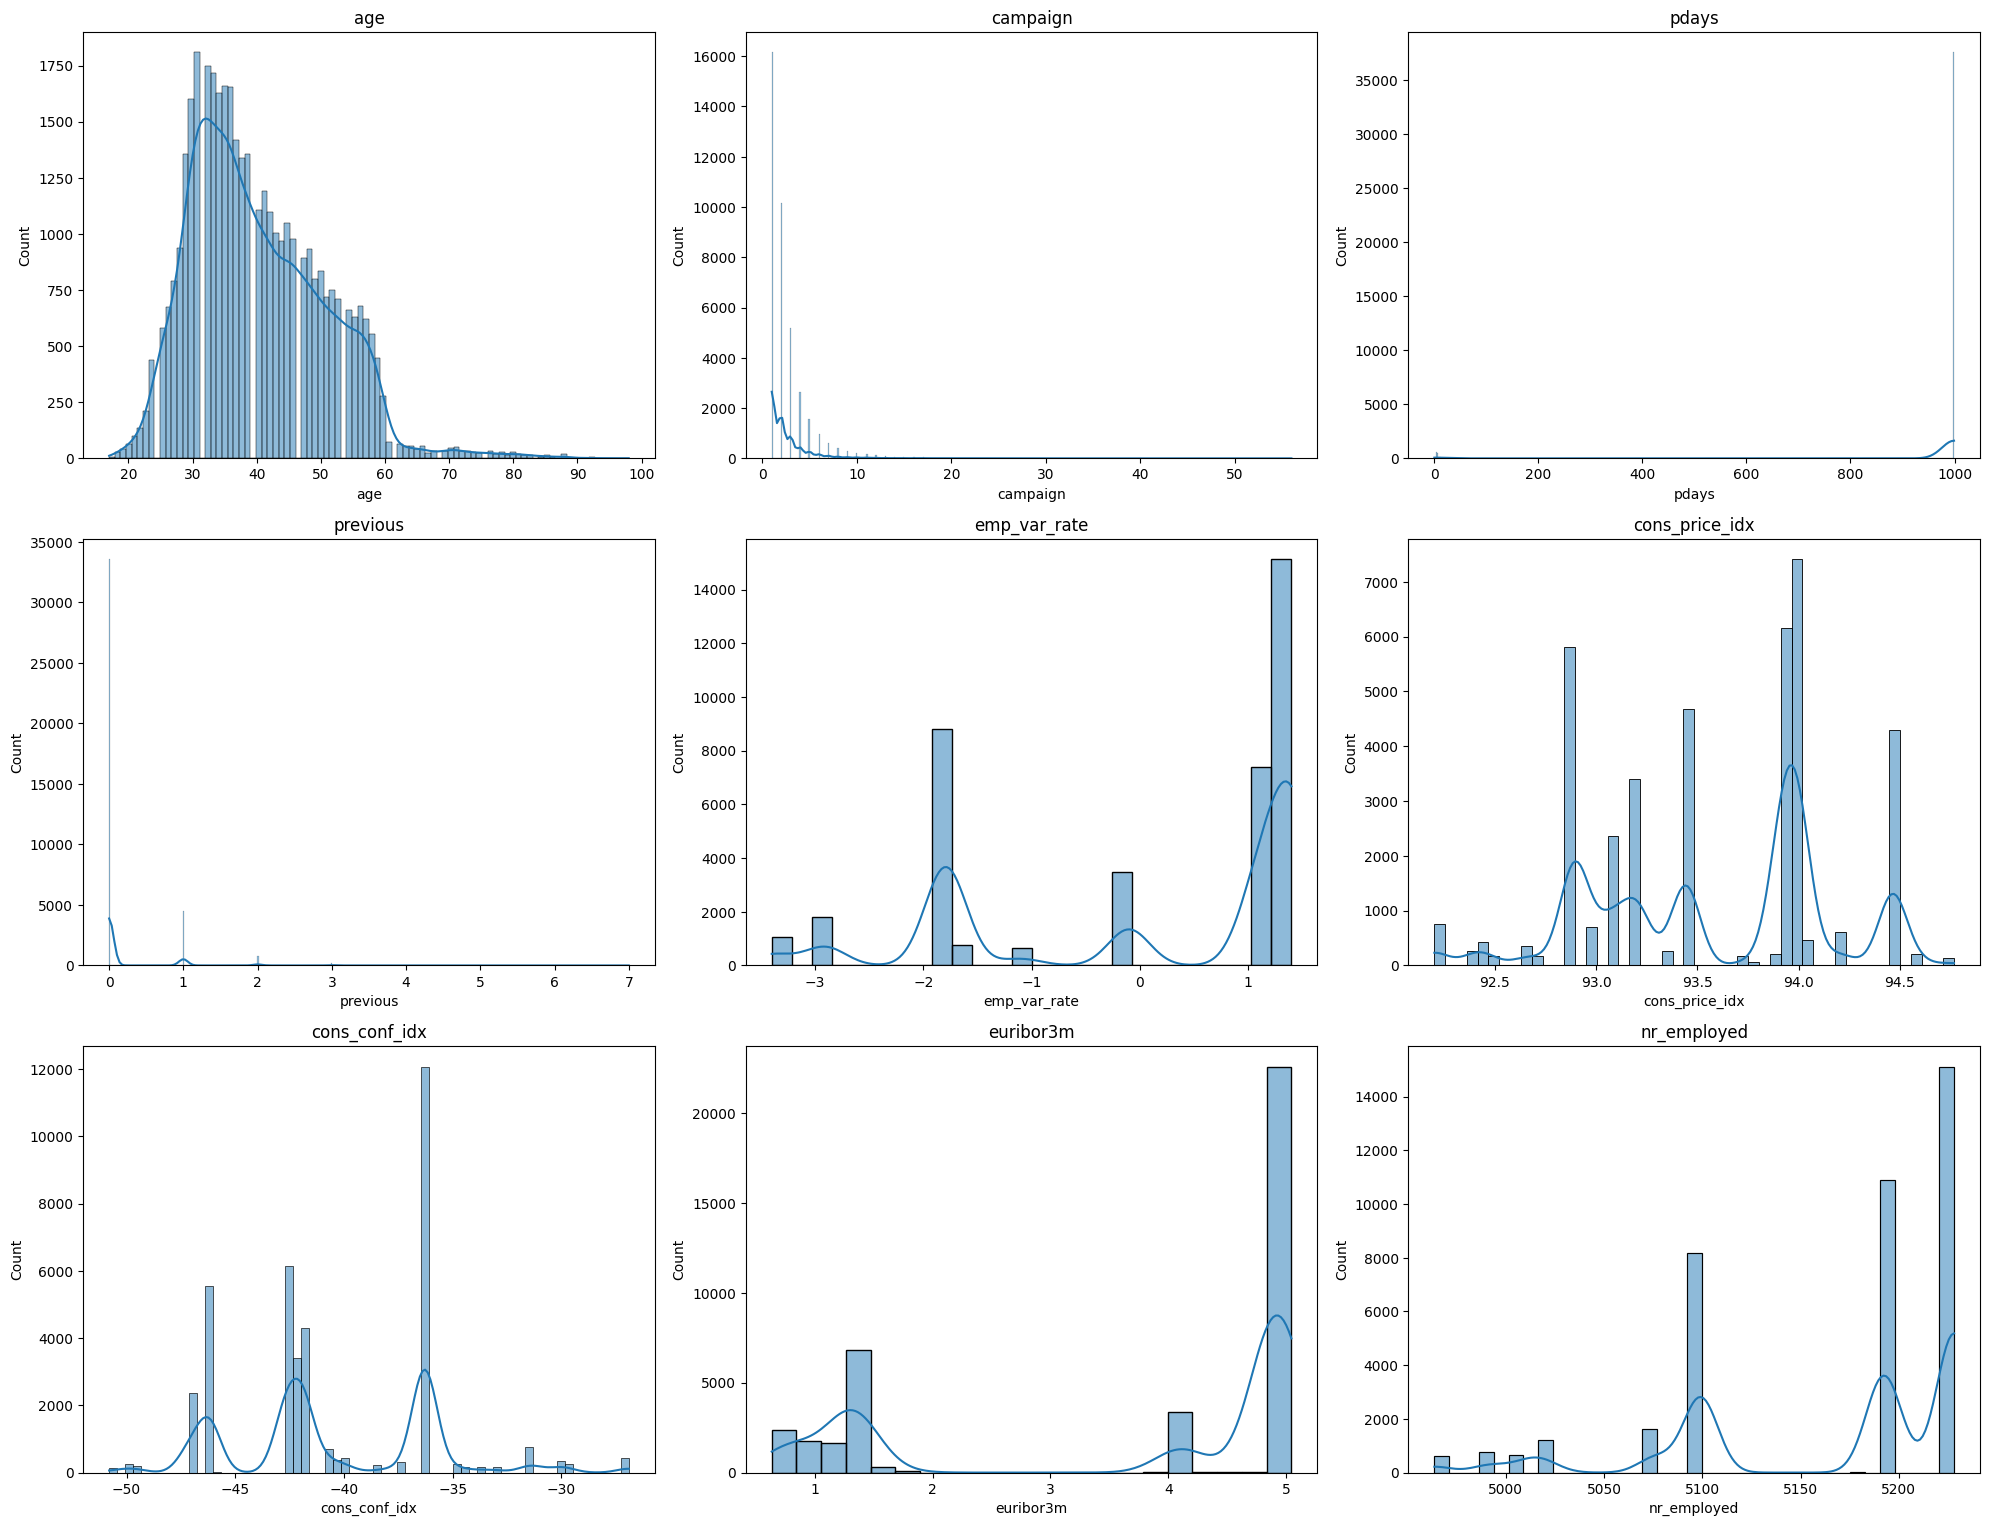

In [342]:
plt.figure(figsize=(20,20))

for i, col in enumerate(df.select_dtypes(include=['number']).columns[:16], 1):
    plt.subplot(4,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


In [343]:
# 🧾 Report About User-Defined Functions

# I genuinely state that this user-defined function was created with the help of 'AI TOOLS' to make my work faster and more efficient.
# We have AI tools that help us complete tasks quickly — learning every single piece of code from scratch is not always possible for the human brain.
# My intention is only to use AI for learning and productivity, not for misuse amd harm company's data
# This function helps data scientists save time and generate clear visualizations instead of writing long, repetitive code blocks.

# if i need any customization i will update my function otherwise write manual code using pyplot and seaborn


def plot_columns(df, columns, plot_type='count', n_cols=3, main_title=None, target=None, theme='Set2'):
    
    
    """
    Smart plotting function for EDA — creates multiple plots in grid layout.

    Parameters:
    -----------
    df : pandas.DataFrame
        Dataset to plot.
    columns : list
        List of column names to visualize.
    plot_type : str
        Type of plot. Choose from: 'count', 'hist', 'box', 'violin'
    n_cols : int
        Number of plots per row (default = 3)
    main_title : str
        Optional main title for the figure.
    target : str or None
        Optional target variable for hue (e.g., 'y')
    theme : str
        Choose plot color theme: 'Set2', 'coolwarm', or 'skyblue'
    """
    import math


    # Validate theme
    valid_themes = ['Set2', 'coolwarm', 'skyblue']
    if theme not in valid_themes:
        print(f"⚠️ Invalid theme! Using default 'Set2'.")
        theme = 'Set2'

    # Handle theme settings
    if theme == 'skyblue':
        palette = None
        color = 'skyblue'
    else:
        palette = theme
        color = None

    # Safety: Limit max plots
    max_plots = 12
    if len(columns) > max_plots:
        print(f"⚠️ Too many columns! Showing first {max_plots} only.")
        columns = columns[:max_plots]

    n_plots = len(columns)
    n_rows = math.ceil(n_plots / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(columns, 1):
        plt.subplot(n_rows, n_cols, i)

        # Select hue only if target is provided
        hue_param = target if target else None

        # ---- Choose plot type ----
        if plot_type == 'count':
            sns.countplot(data=df, x=col, hue=hue_param, palette=palette, color=color)
        elif plot_type == 'hist':
            sns.histplot(data=df, x=col, hue=hue_param, kde=True, palette=palette, color=color)
        elif plot_type == 'box':
            if hue_param:
                sns.boxplot(data=df, x=hue_param, y=col, palette=palette, color=color)
            else:
                sns.boxplot(data=df, y=col, palette=palette, color=color)
        elif plot_type == 'violin':
            if hue_param:
                sns.violinplot(data=df, x=hue_param, y=col, palette=palette, color=color)
            else:
                sns.violinplot(data=df, y=col, palette=palette, color=color)
        else:
            raise ValueError("Invalid plot_type. Use: 'count', 'hist', 'box', or 'violin'")

        plt.title(f"{col}", fontsize=12)
        plt.xticks(rotation=45)
        plt.tight_layout()

    if main_title:
        plt.suptitle(main_title, fontsize=16, y=1.02)

    plt.show()


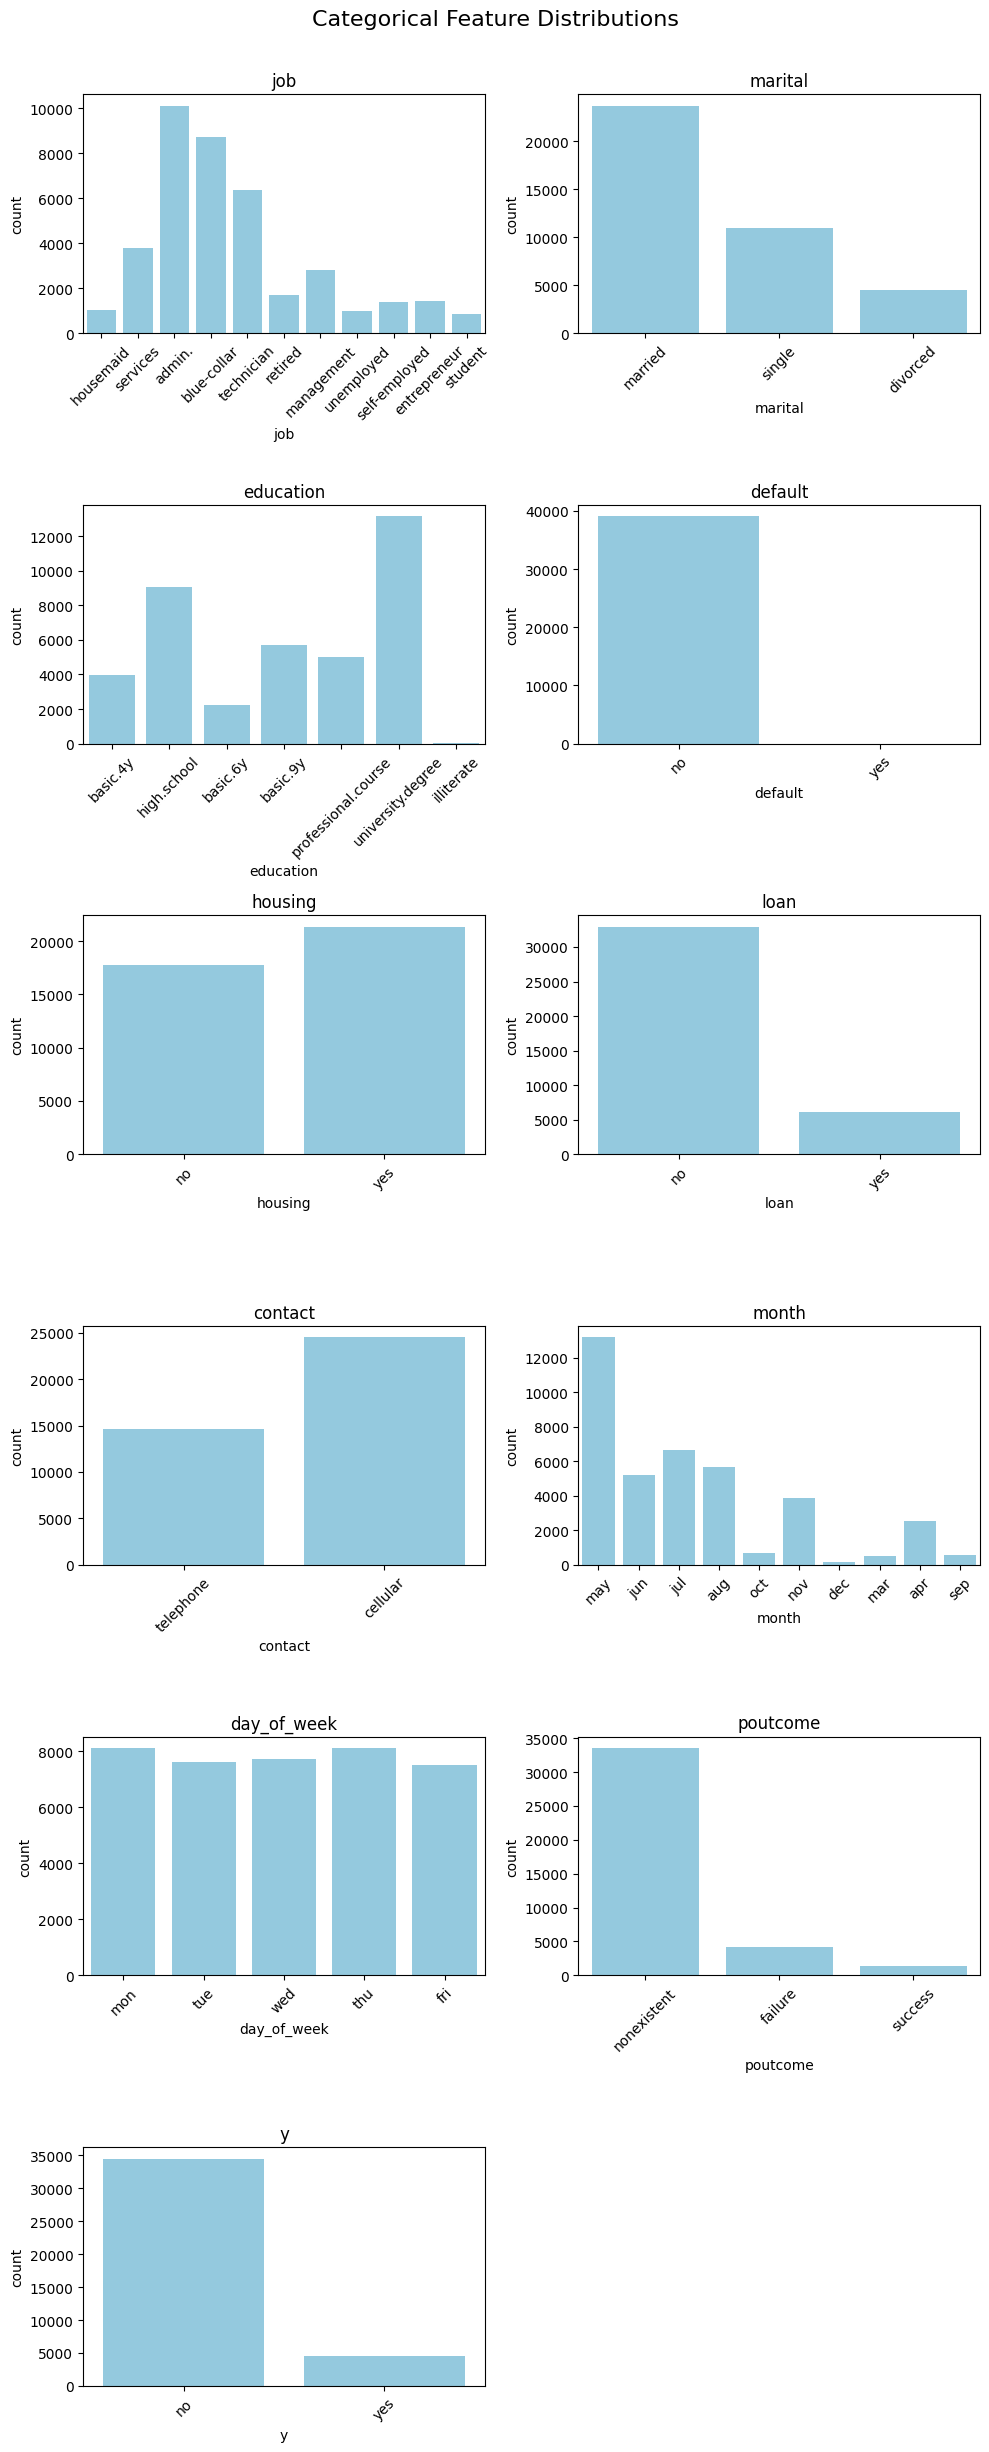

In [344]:


cat_cols = df.select_dtypes(include="object")
# print(cat_cols.columns)

plot_columns(df, ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'], plot_type='count',n_cols=2, main_title='Categorical Feature Distributions',theme='skyblue')


## bivariate analysis (feature vs target)



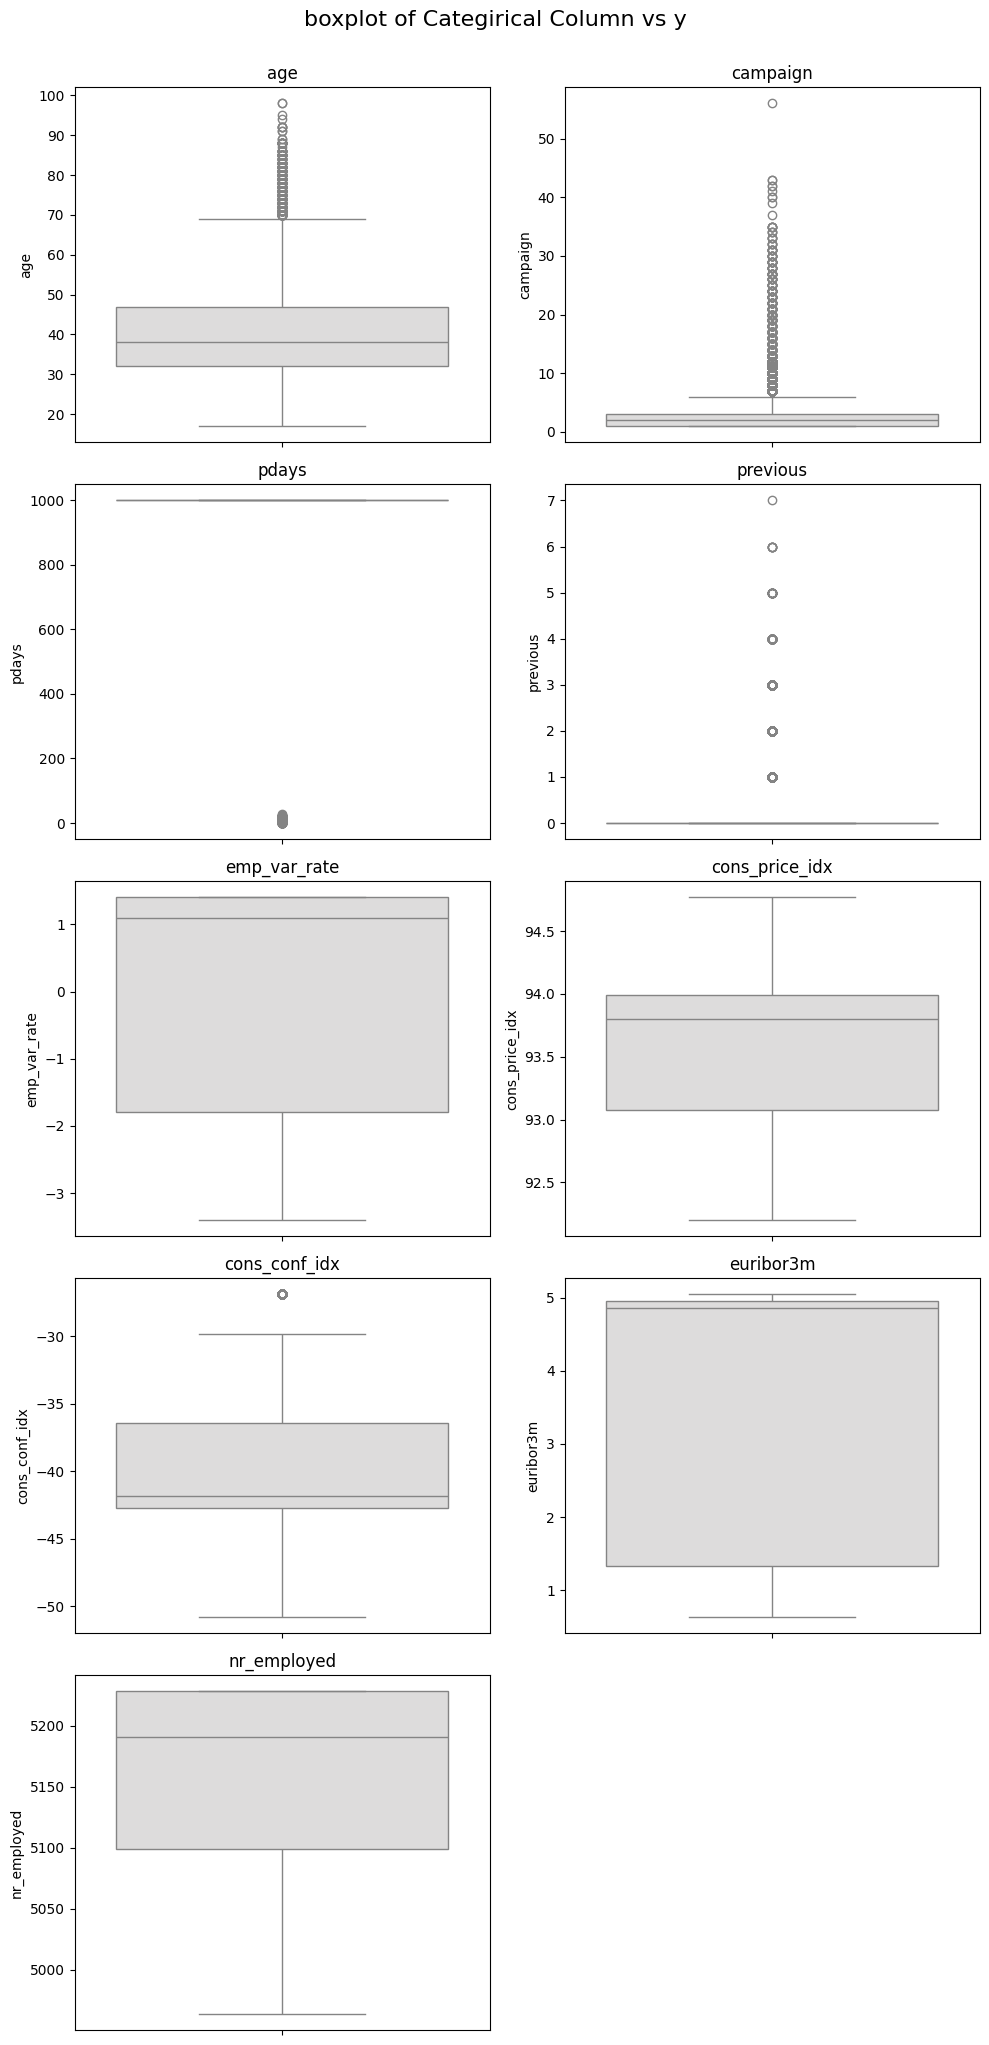

In [345]:
#  Numerical Column

plot_columns(df,
             ['age', 'campaign', 'pdays', 'previous', 'emp_var_rate','cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed'],
             n_cols=2,plot_type='box',main_title="boxplot of Categirical Column vs y",theme="coolwarm"
        )


In [346]:
#  boxplot is for checking outliers and categorical column cant have outliers

In [347]:
print(num_col)
print(cat_cols.columns)

Index(['age', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed'],
      dtype='object')
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


In [348]:
# df.to_csv("updated v1.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39079 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             39079 non-null  int64  
 1   job             39079 non-null  object 
 2   marital         39079 non-null  object 
 3   education       39079 non-null  object 
 4   default         39079 non-null  object 
 5   housing         39079 non-null  object 
 6   loan            39079 non-null  object 
 7   contact         39079 non-null  object 
 8   month           39079 non-null  object 
 9   day_of_week     39079 non-null  object 
 10  campaign        39079 non-null  int64  
 11  pdays           39079 non-null  int64  
 12  previous        39079 non-null  int64  
 13  poutcome        39079 non-null  object 
 14  emp_var_rate    39079 non-null  float64
 15  cons_price_idx  39079 non-null  float64
 16  cons_conf_idx   39079 non-null  float64
 17  euribor3m       39079 non-null  floa

In [349]:

num_col = df.select_dtypes(include=['int64','float64']).columns
cat_col = df.select_dtypes(include=['object']).columns



In [350]:
# from this analysis : ['default',  'contact'] colums dooes not affect the target so its better to delete them

# df.drop(['default', 'poutcome', 'loan', 'contact'],axis = 1,  inplace=True)

## Correlation Analysis 

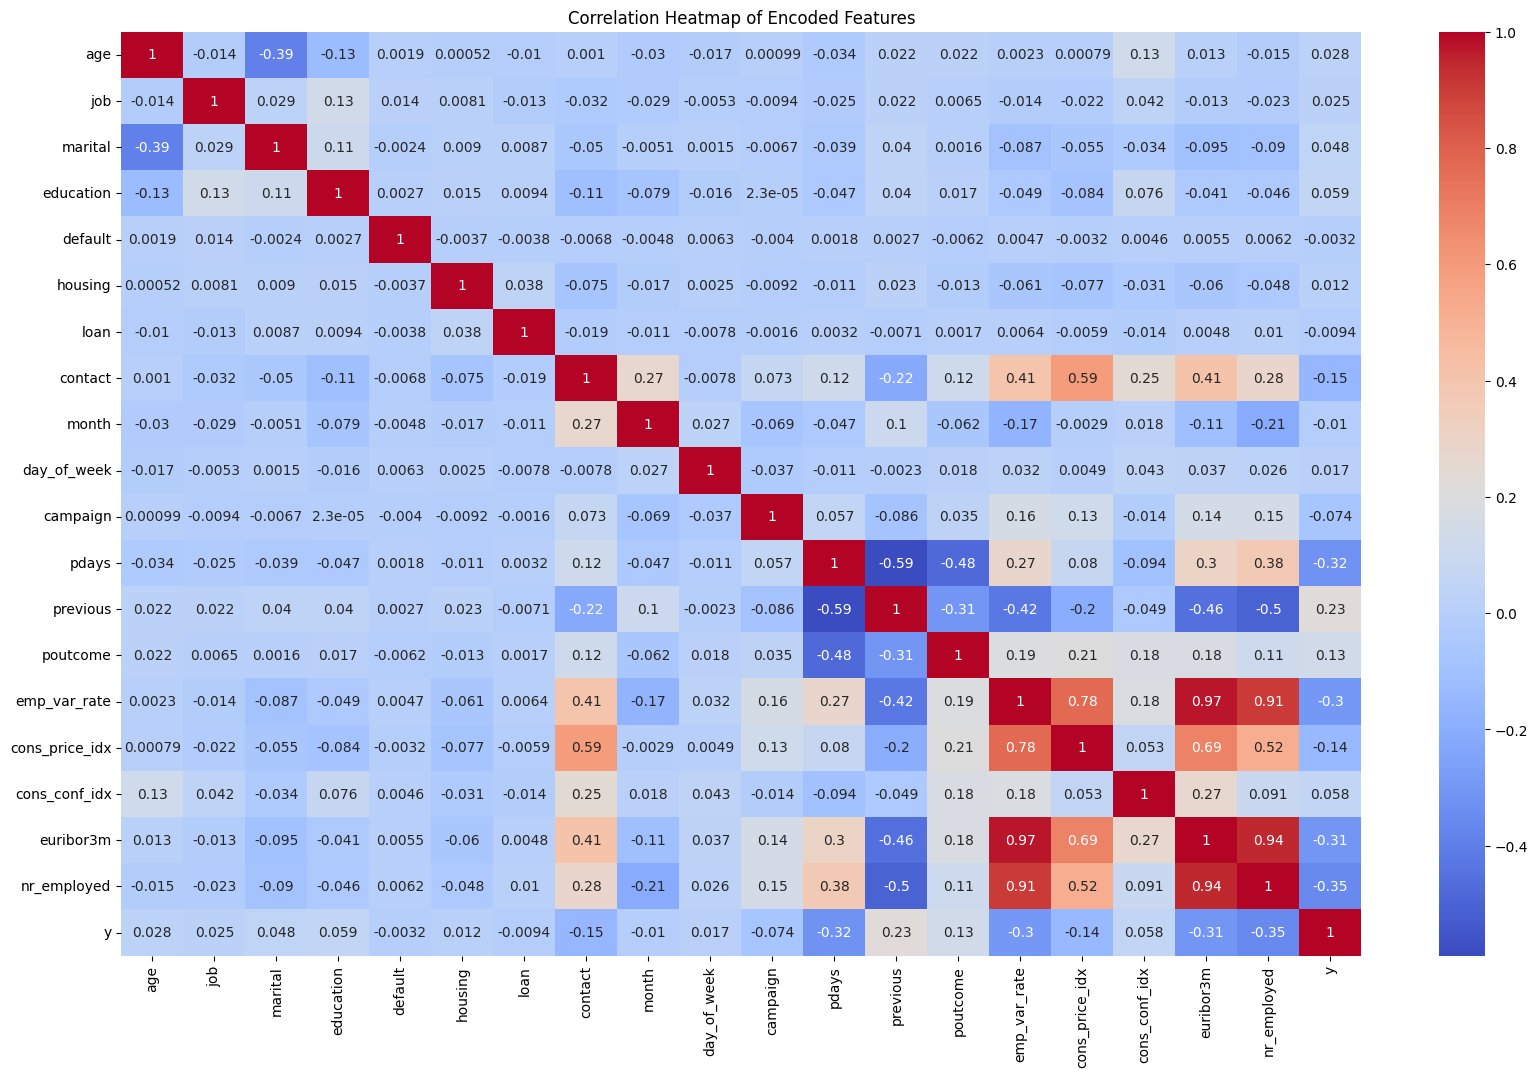

In [351]:
from sklearn.preprocessing import LabelEncoder
df1 = df.copy()
for col in df1.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df1[col] = le.fit_transform(df1[col])



plt.figure(figsize=(20,12))
sns.heatmap(df1.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Encoded Features")
plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [352]:
for col in df:
    print(col," : ",df[col].unique().tolist())

age  :  [56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 54, 46, 50, 39, 30, 55, 49, 34, 52, 58, 32, 38, 44, 42, 60, 53, 47, 51, 48, 33, 31, 43, 36, 28, 27, 26, 22, 23, 20, 21, 61, 19, 18, 70, 66, 76, 67, 73, 88, 95, 77, 68, 75, 63, 80, 62, 65, 72, 82, 64, 71, 69, 78, 85, 79, 83, 81, 74, 17, 87, 91, 86, 98, 94, 84, 92, 89]
job  :  ['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'entrepreneur', 'student']
marital  :  ['married', 'single', 'divorced']
education  :  ['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'university.degree', 'illiterate']
default  :  ['no', 'yes']
housing  :  ['no', 'yes']
loan  :  ['no', 'yes']
contact  :  ['telephone', 'cellular']
month  :  ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
day_of_week  :  ['mon', 'tue', 'wed', 'thu', 'fri']
campaign  :  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 19, 18, 23, 14, 22, 25, 16, 17, 15, 20, 56, 39, 35

## Outliers

In [353]:
# for col in df.select_dtypes(include=['int64','float64']):
#     plt.figure()
#     sns.boxplot(x=df[col])

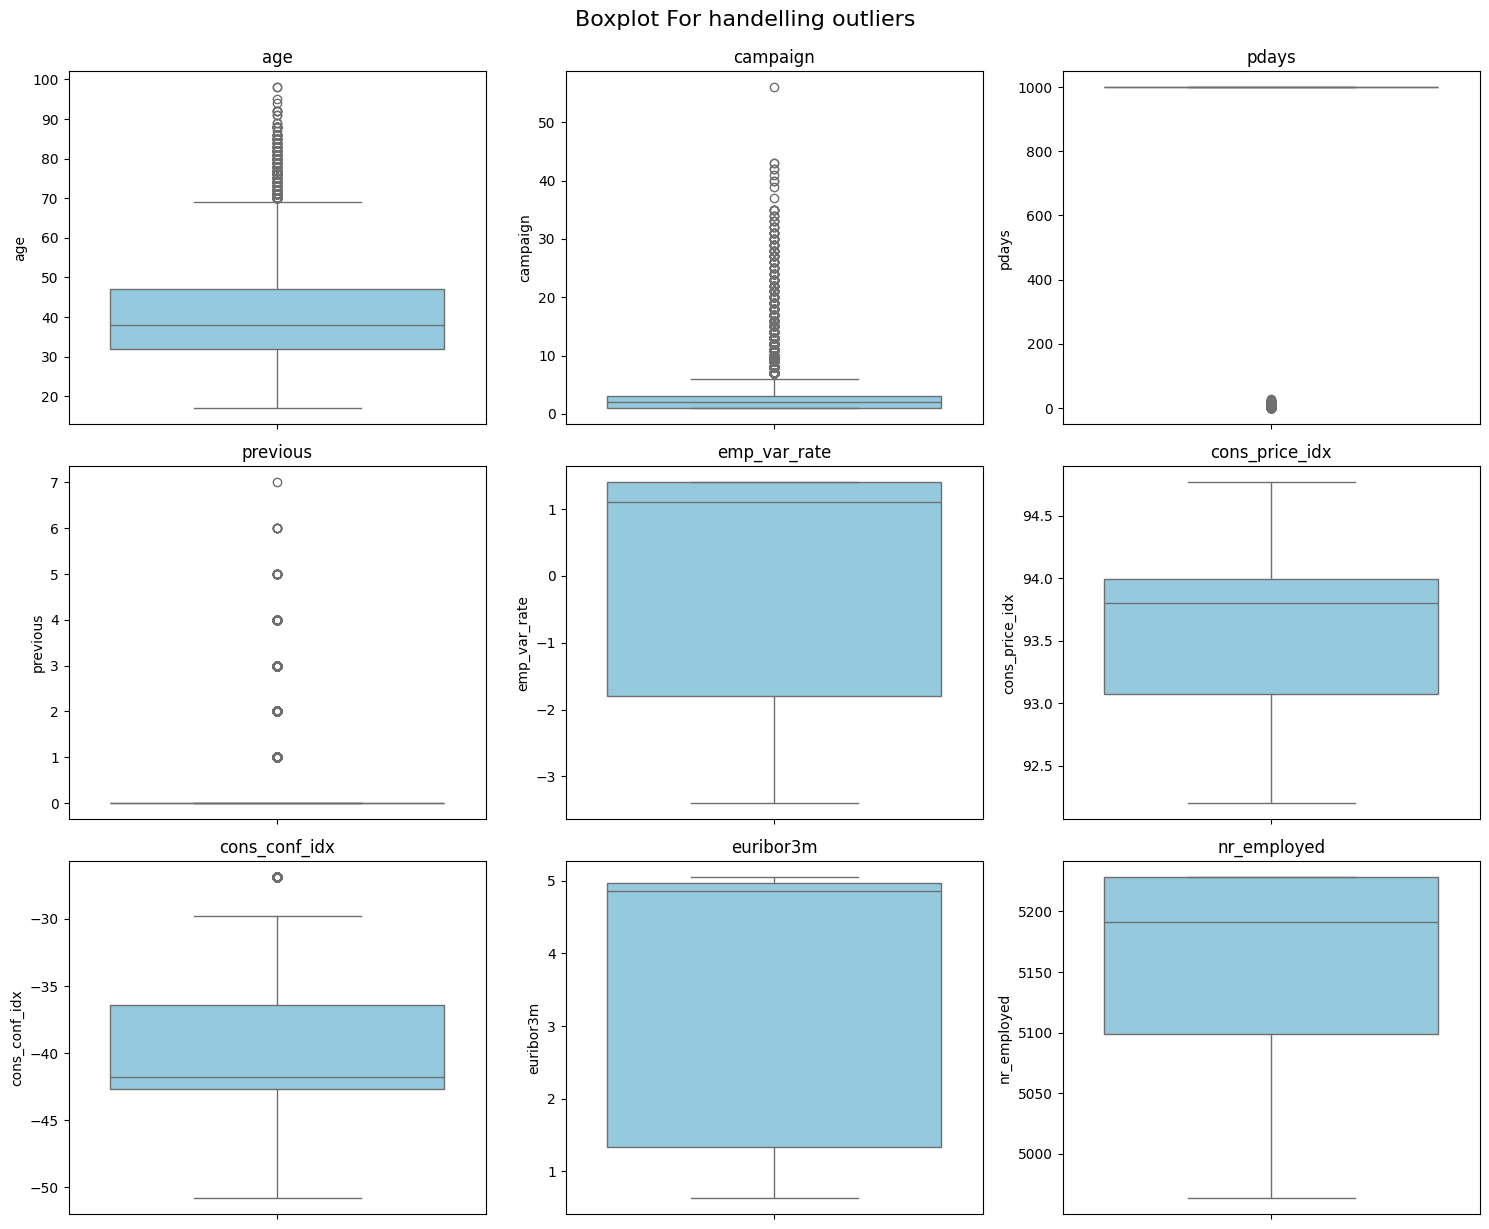

In [354]:
# num_col
plot_columns(df,['age', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed'],
       plot_type='box',n_cols=3,main_title="Boxplot For handelling outliers",
       theme="skyblue")

In [355]:
# outliers in col [ 'age', 'duration', 'capaign'  ] 

In [356]:
df[['age','campaign']].describe()

,age,campaign
count,39079.000000,39079.000000
mean,40.121114,2.627780
std,10.475117,2.823201
min,17.000000,1.000000
25%,32.000000,1.000000
50%,38.000000,2.000000
75%,47.000000,3.000000
max,98.000000,56.000000


In [357]:
'''
IQR Rule Formula : Q3 - Q1 
lower bound = Q1 - 1.5 * IQR
higher bound = Q3 + 1.5 * IQR

if (value < lower bound) and (value > higher bound)  = outlier

'''


'\nIQR Rule Formula : Q3 - Q1 \nlower bound = Q1 - 1.5 * IQR\nhigher bound = Q3 + 1.5 * IQR\n\nif (value < lower bound) and (value > higher bound)  = outlier\n\n'

In [358]:
q1 = df['age'].quantile(.25)
q2 = df['age'].quantile(.50)
q3 = df['age'].quantile(.75)
q4 = df['age'].quantile(1)

iqr = q3 - q1 # 15
lb = q1 - 1.5 * iqr
hb = q3 + 1.5 * iqr

outlier = df[(df.age > hb) | (df.age < lb)]
outlier.shape

(457, 20)

In [359]:
outlier[outlier['age']>95]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
38452,98,retired,married,basic.4y,no,yes,no,cellular,oct,fri,1,2,2,success,-3.4,92.431,-26.9,0.73,5017.5,yes
38455,98,retired,married,basic.4y,no,yes,no,cellular,oct,fri,2,999,0,nonexistent,-3.4,92.431,-26.9,0.73,5017.5,yes


In [360]:
# removing all outliers cause data loss 
df.age.max()  # 98
# logically i am removinng age > 80

df = df[df['age'] <=80]
    
df['age'].max()


np.int64(80)

<Axes: ylabel='age'>

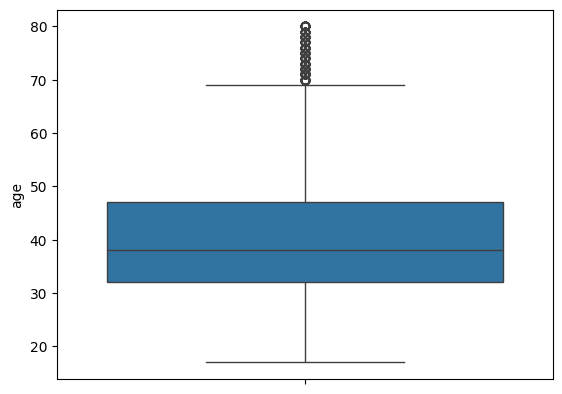

In [361]:
# let see outliers in boxplot
sns.boxplot(data=df.age)

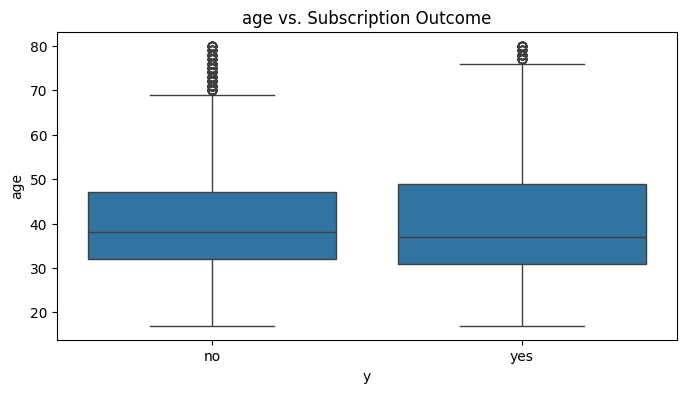

In [362]:
plt.figure(figsize=(8,4))
sns.boxplot(x='y',y='age',data=df)
plt.title("age vs. Subscription Outcome")
# plt.show()
plt.savefig("agge vs. Subscription Outcome.png",dpi=300 , bbox_inches='tight' )

In [363]:
# lets handle campaign outlier 

q1 = df['campaign'].quantile(.25)
q2 = df['campaign'].quantile(.50)
q3 = df['campaign'].quantile(.75)
q4 = df['campaign'].quantile(1)

iqr = q3 - q1 # 15
lb = q1 - 1.5 * iqr
hb = q3 + 1.5 * iqr

outlier = df[(df.campaign > hb) | (df.campaign < lb)]
outlier.shape


(2392, 20)

<Axes: ylabel='campaign'>

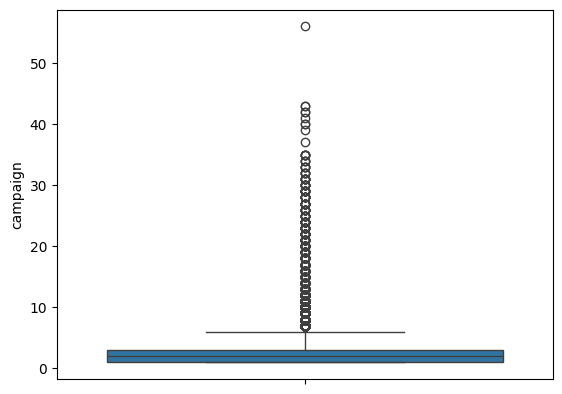

In [364]:
sns.boxplot(data=df['campaign'])

In [365]:
df[(df['campaign']>15) & (df['y'] == 1) ]

# Almost no one who was called more than 15 times actually bought the product.

# 5 / df.shape[0] *100   --> 0.01%


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y


In [366]:
4451 / df.shape[0] *100 

#  10 % outliers in campaign

11.423365157581356

<Axes: ylabel='campaign'>

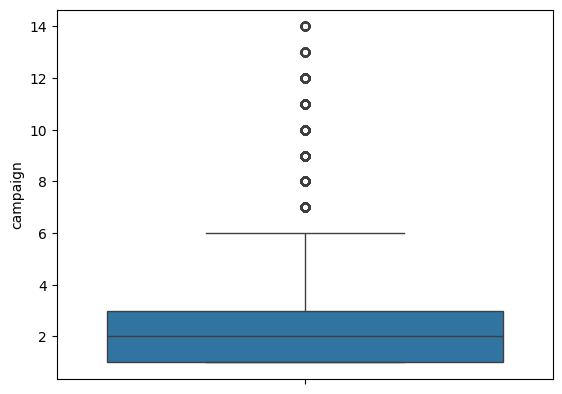

In [367]:
# If a customer hasn’t agreed after 15 calls, they probably never will.

# Continuing to call them wastes time, money, and human resources.

# It’s smarter for the bank to redirect those calls to new customers instead.

# — removing those entries (or capping at 15) is justified and data-driven.

df = df[df['campaign'] < 15]

sns.boxplot(data=df['campaign'])

In [368]:
df.shape

(38558, 20)

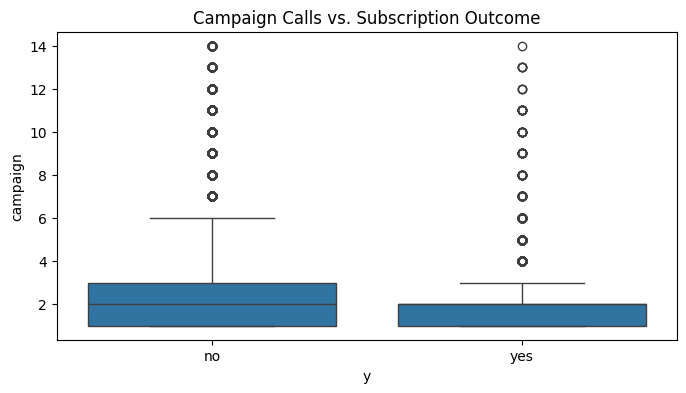

In [369]:
plt.figure(figsize=(8,4))
sns.boxplot(x='y',y='campaign',data=df)
plt.title("Campaign Calls vs. Subscription Outcome")
# plt.show()
plt.savefig("Campaign Calls vs. Subscription Outcome.png",dpi=300 , bbox_inches='tight' )

In [370]:
# ohh no by viz... this we can see outliers are more than 6
df = df[df['campaign'] < 6]


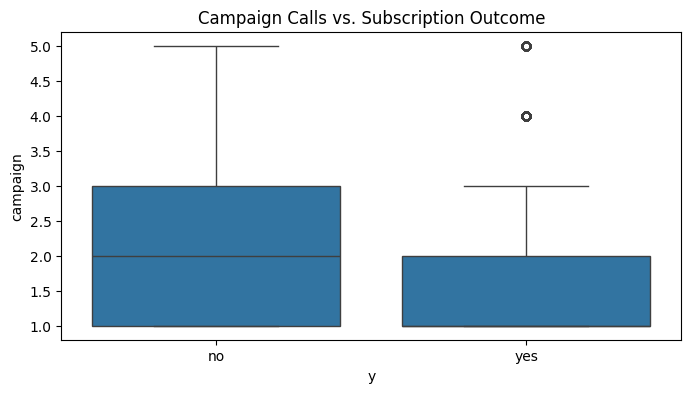

In [371]:
plt.figure(figsize=(8,4))
sns.boxplot(x='y',y='campaign',data=df)
plt.title("Campaign Calls vs. Subscription Outcome")
# plt.show()
plt.savefig("Campaign Calls vs. Subscription Outcome.png",dpi=300 , bbox_inches='tight' )

## EDA Final Summmary

1. loaded the data 
2. replaced the miissiing value with mode for categorical data
3. for plotting box i made user defined function
4. from heatmap -
        1) duration affects the positively with target column
        2) pdays, nr_employeed affects negatively to target
5. handelling outliers -
    three columns  has outliers age, duration annd campaign
    handelled 70% outliers there; why 30% not -> sometimes outliers deletion cause data loss so if model does not trainn properly i will remove the remain 30 % outliers




In [372]:
num_col


Index(['age', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed'],
      dtype='object')

In [373]:
for col in cat_col:
    print(pd.crosstab(df[col],df['y']) , end ="\n-------------------\n")

# pd.crosstab(df['age'],df['y'])


y                no   yes
job                      
admin.         7862  1311
blue-collar    7361   607
entrepreneur   1183   115
housemaid       821    98
management     2281   311
retired        1095   367
self-employed  1124   142
services       3128   304
student         541   269
technician     5091   696
unemployed      761   136
-------------------
y            no   yes
marital              
divorced   3575   419
married   19210  2388
single     8463  1549
-------------------
y                       no   yes
education                       
basic.4y              3150   376
basic.6y              1834   181
basic.9y              4817   442
high.school           7290   981
illiterate              13     4
professional.course   3981   564
university.degree    10163  1808
-------------------
y           no   yes
default             
no       31245  4356
yes          3     0
-------------------
y           no   yes
housing             
no       14242  1902
yes      17006  2454
-------

In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35604 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35604 non-null  int64  
 1   job             35604 non-null  object 
 2   marital         35604 non-null  object 
 3   education       35604 non-null  object 
 4   default         35604 non-null  object 
 5   housing         35604 non-null  object 
 6   loan            35604 non-null  object 
 7   contact         35604 non-null  object 
 8   month           35604 non-null  object 
 9   day_of_week     35604 non-null  object 
 10  campaign        35604 non-null  int64  
 11  pdays           35604 non-null  int64  
 12  previous        35604 non-null  int64  
 13  poutcome        35604 non-null  object 
 14  emp_var_rate    35604 non-null  float64
 15  cons_price_idx  35604 non-null  float64
 16  cons_conf_idx   35604 non-null  float64
 17  euribor3m       35604 non-null  floa

# Label Encoding For Categorical Data

In [375]:
#  encode data object into float 

from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # store encoder for future decoding
df.head()


# # ---------- DECODING ----------
# # When you want to get original categorical values back:
# for col, le in label_encoders.items():
#     df[col] = le.inverse_transform(df[col])

# print("✅ Decoding completed. Data restored to original categories.")



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


# converting data into new csv file for making pipeline

In [376]:
df.to_csv("Pipeline.csv")

# Lets Test With Multiple Models

## SPLIT THE DATA

In [377]:
from sklearn.model_selection import train_test_split



# feature and target
X = df.drop('y',axis=1)
y = df['y']

print(df['y'].value_counts())
print("------------")



X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42, stratify=y )

y
0    31248
1     4356
Name: count, dtype: int64
------------


## SMOTE

In [378]:

# Applying the smote 
from imblearn.over_sampling import SMOTE
# creating smote object
sm = SMOTE(random_state=42)

# applying resample for your training data
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before: ", y_train.value_counts() )
print("After: ",  y_train_res.value_counts())

#  after smote

# Accuracy went down because the model now takes more “risks” predicting “yes.”
# In marketing, 
# it’s better to wrongly contact some “no” customers 
# than to miss potential “yes” customers.


Before:  y
0    24998
1     3485
Name: count, dtype: int64
After:  y
1    24998
0    24998
Name: count, dtype: int64


## Feature Scalling / Columns Scalling

### types : standardscalling, minmaxscalling

In [379]:
#  standard scalling --> Z score Normalization ( -3 to +3 , mean = 0 )

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res) # fit-transform ---> training 
X_test_scaled = scaler.transform(X_test)   # transform ---> testing


# Logistic regression model

In [380]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score as acs , confusion_matrix as cfm ,classification_report as cfr

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train_res)



y_pred_log = logistic_model.predict(X_test_scaled)

print("✅ Accuracy:", acs(y_test, y_pred_log))
print("\nConfusion Matrix:\n", cfm(y_test, y_pred_log))
print("\nClassification Report:\n", cfr(y_test, y_pred_log))

✅ Accuracy: 0.7786827692739784

Confusion Matrix:
 [[5048 1202]
 [ 374  497]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.86      6250
           1       0.29      0.57      0.39       871

    accuracy                           0.78      7121
   macro avg       0.61      0.69      0.63      7121
weighted avg       0.85      0.78      0.81      7121




#### for class 1 
#### precision  -> all predicted yes are 68% true
#### recall -> all predicted yes 25% found
###
#### fi-score -> balance between precision and recall / 
#### if low f1 score -> is not good at model to predict yes  
### 
###
####   confision matrix insights 
###
###
####  Confusion Matrix:
####  [[6144    106] -> [true_no    false_yes] 
####  [ 650    221]] -> [false_no    true_yes]



In [381]:
# The Real Issue → Imbalanced Target

# In  dataset:

# Most clients say “no” (~89%)

# Few say “yes” (~11%)

# model is doing great at predicting “no”, but failing to capture the minority “yes”.

## vizz... confusion matrix

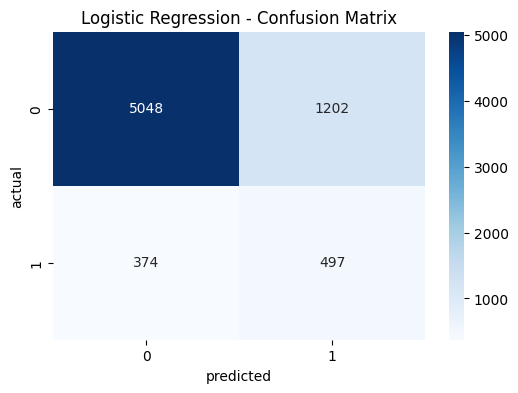

In [382]:
plt.figure(figsize=(6,4))
sns.heatmap(cfm(y_test,y_pred_log),annot=True,cmap='Blues',fmt = 'd')
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


In [383]:
df.head() # data is encoded

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [384]:
print(X_train_res.value_counts().sum())
print(y_train_res.value_counts().sum())

#  data is balanced using SMOTE


49996
49996


# Random Forest Model

In [385]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

random_f_model = RandomForestClassifier(random_state= 42, n_estimators=100)
#  in this model no need of scaled data
random_f_model.fit(X_train_res,y_train_res)
y_pred_rf = random_f_model.predict(X_test)

print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf ))
print()
print("classification report:", classification_report(y_test, y_pred_rf))
print()
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy:  0.8618171605111642

classification report:               precision    recall  f1-score   support

           0       0.92      0.92      0.92      6250
           1       0.44      0.44      0.44       871

    accuracy                           0.86      7121
   macro avg       0.68      0.68      0.68      7121
weighted avg       0.86      0.86      0.86      7121


Confusion matrix:
 [[5756  494]
 [ 490  381]]


# K NEAREST NEIGHBOUR

In [386]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled,y_train_res)

y_pred_knn = knn_model.predict(X_test_scaled)

print("knn accuracy : ",accuracy_score(y_test, y_pred_knn))
print()
print("classification report : \n",classification_report(y_test, y_pred_knn))

knn accuracy :  0.7656228057857043

classification report : 
               precision    recall  f1-score   support

           0       0.92      0.80      0.86      6250
           1       0.27      0.53      0.36       871

    accuracy                           0.77      7121
   macro avg       0.60      0.66      0.61      7121
weighted avg       0.84      0.77      0.80      7121



## SVM ( SUpport Vector Machine )

In [387]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf',random_state=42)
svm_model.fit(X_train_scaled,y_train_res)

# prediction
y_pred_svm = svm_model.predict(X_test_scaled)

# evaluate
print("Accuracy SVM :",accuracy_score(y_test , y_pred_svm))
print()
print("Classification Report :",classification_report(y_test , y_pred_svm))
print()
print("confusion matrix\n",confusion_matrix(y_test , y_pred_svm))
print()


Accuracy SVM : 0.8109816037073445

Classification Report :               precision    recall  f1-score   support

           0       0.94      0.84      0.89      6250
           1       0.34      0.58      0.43       871

    accuracy                           0.81      7121
   macro avg       0.64      0.71      0.66      7121
weighted avg       0.86      0.81      0.83      7121


confusion matrix
 [[5268  982]
 [ 364  507]]



## XGBoost

In [388]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier()

xgb_model.fit(X_train_res,y_train_res)

y_pred_xg = xgb_model.predict(X_test)

print("XGBoosting accuracy: ",accuracy_score(y_test,y_pred_xg))
print()
print("classification report : \n: ",classification_report(y_test,y_pred_xg))

XGBoosting accuracy:  0.8556382530543463

classification report : 
:                precision    recall  f1-score   support

           0       0.92      0.91      0.92      6250
           1       0.42      0.45      0.43       871

    accuracy                           0.86      7121
   macro avg       0.67      0.68      0.67      7121
weighted avg       0.86      0.86      0.86      7121



In [389]:
models = ['logistic','random forest','k nearest neighbor','SVM','XGBoost']

accuracy = [
    accuracy_score(y_test, y_pred_log),        # logistic from earlier
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_xg)

]

comparison = pd.DataFrame({'Model':models, 'Accuracy':accuracy})
print(comparison.sort_values(by='Accuracy',ascending=False))



                Model  Accuracy
1       random forest  0.861817
4             XGBoost  0.855638
3                 SVM  0.810982
0            logistic  0.778683
2  k nearest neighbor  0.765623


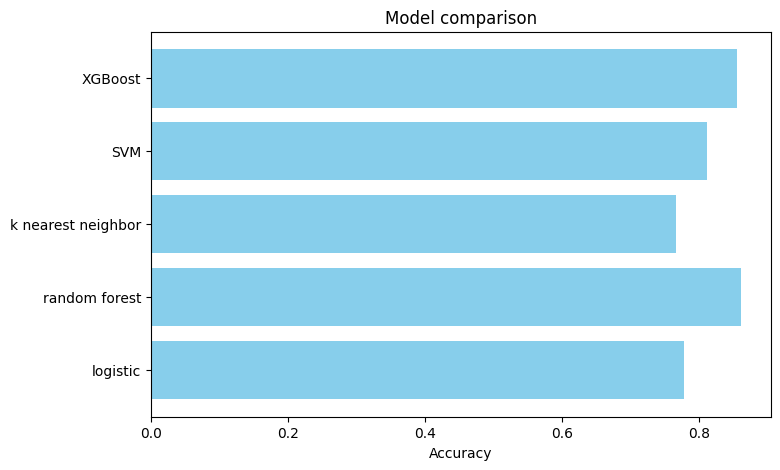

In [390]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(comparison['Model'], comparison['Accuracy'], color= 'skyblue' )
plt.xlabel("Accuracy")
plt.title("Model comparison")
plt.show()

In [391]:

l1=["logistic","randomforest","knn","svm","xgboost"]


from sklearn.metrics import precision_score, recall_score, f1_score

comparison = []

for name, preds in zip(l1, [y_pred_log, y_pred_rf, y_pred_knn, 
                            y_pred_svm, 
                            y_pred_xg]):
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (Yes)': precision_score(y_test, preds),
        'Recall (Yes)': recall_score(y_test, preds),
        'F1-Score (Yes)': f1_score(y_test, preds)
    })

import pandas as pd
comparison_df = pd.DataFrame(comparison).sort_values(by='F1-Score (Yes)', ascending=False)
print(comparison_df)


          Model  Accuracy  Precision (Yes)  Recall (Yes)  F1-Score (Yes)
1  randomforest  0.861817         0.435429      0.437428        0.436426
4       xgboost  0.855638         0.416222      0.447761        0.431416
3           svm  0.810982         0.340497      0.582090        0.429661
0      logistic  0.778683         0.292525      0.570608        0.386770
2           knn  0.765623         0.267753      0.528129        0.355350


# Hyper parameter Tuning

In [392]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.1,1,10],
    'gamma':[1,0.1,0.01],
    'kernel':['rbf']
}

grid = GridSearchCV(SVC(),param_grid, refit=True, verbose=2,cv=5)
# grid.fit(X_train_scaled,y_train_res)
# print(grid.best_params_)


# -------------------------
# during the model training the svm with rbf kernel took significants longer to execute
# due to high datset 30,000 X 20 and smote also increases the data size 
# 
# SVM gives good results but is not suitable for large dataset 
#  


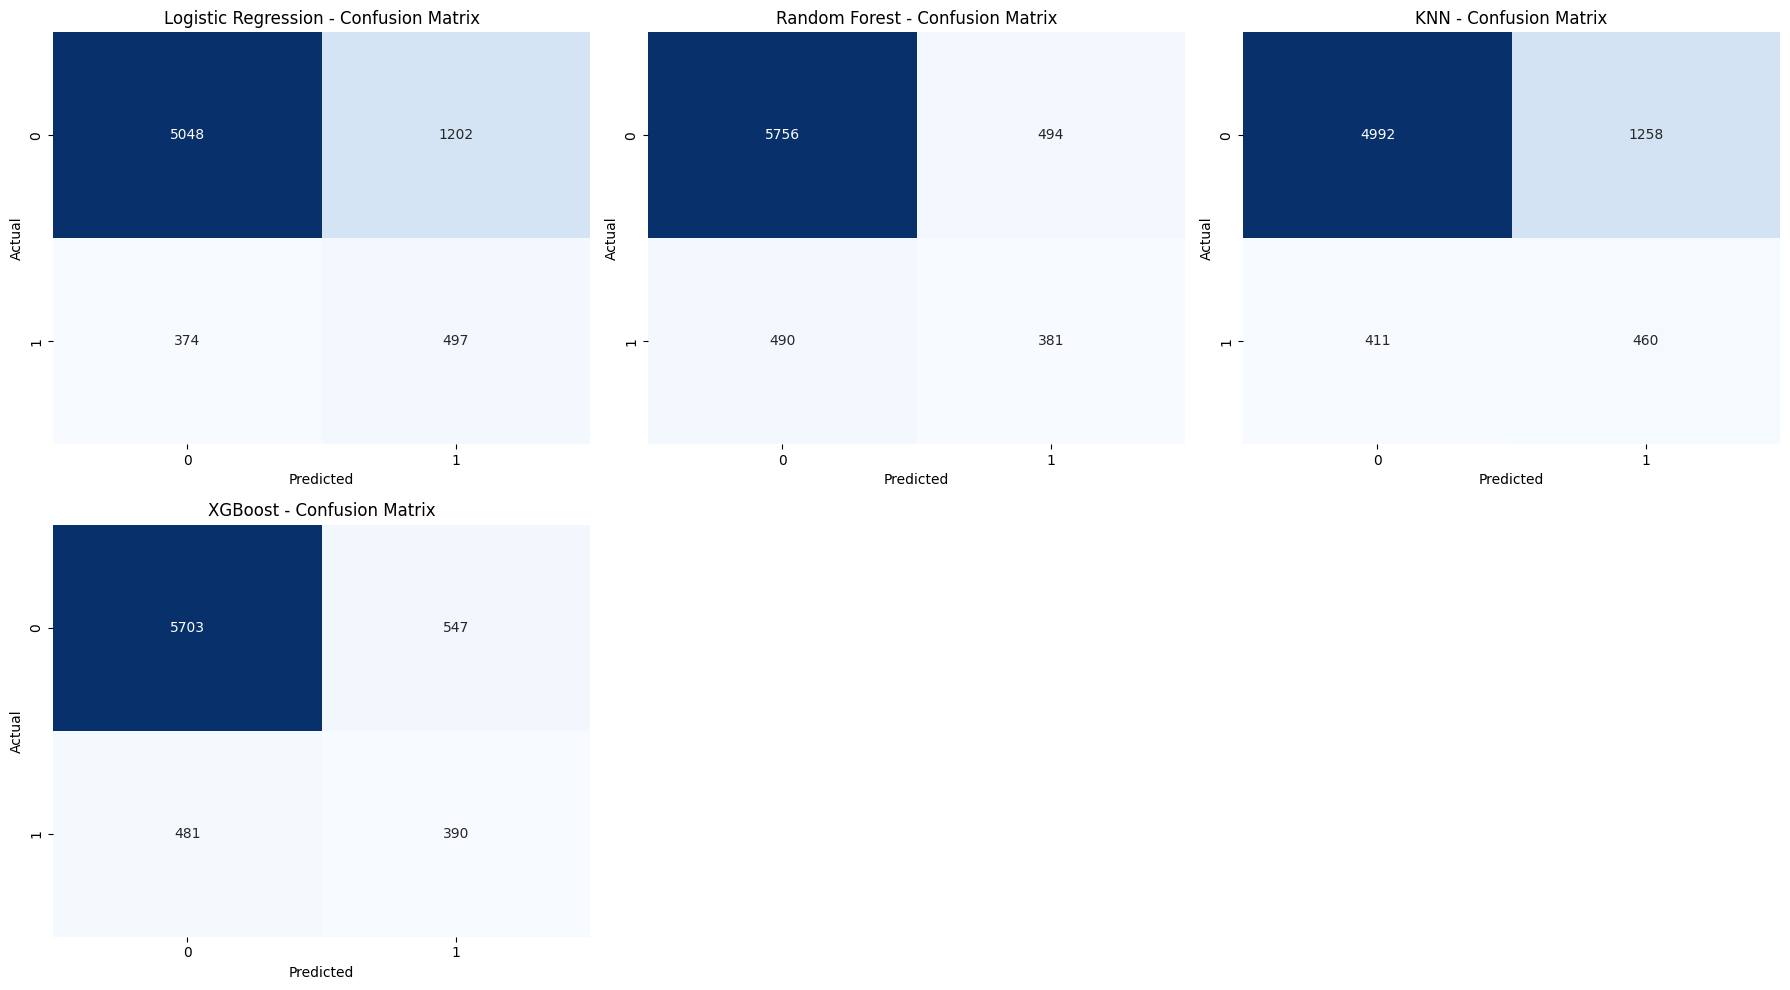

In [393]:
from sklearn.metrics import confusion_matrix as cfm

# confusion matrix of all the models

def plot_confusion_matrices(y_test, predictions_dict):
    """
    Displays confusion matrices for multiple models in 3 columns layout.
    
    Parameters:
        y_test : array-like
            True labels of the test data.
        predictions_dict : dict
            Dictionary with model names as keys and predicted values as values.
            Example: {'Logistic Regression': y_pred_log, 'SVM': y_pred_svm, ...}
    """
    
    n_models = len(predictions_dict)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols   # auto adjust rows
    
    plt.figure(figsize=(18, 5 * n_rows))
    
    for i, (model_name, y_pred) in enumerate(predictions_dict.items(), 1):
        plt.subplot(n_rows, n_cols, i)
        cm = cfm(y_test, y_pred)
        sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', cbar=False)
        plt.title(f"{model_name} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
    
    plt.tight_layout()
    plt.show()


predictions = {
    'Logistic Regression': y_pred_log,
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn,
    # 'SVM': y_pred_svm,
    'XGBoost': y_pred_xg
}

plot_confusion_matrices(y_test, predictions)

In [394]:


# SVM model i am choosing 
# why : because recall : 58%
# highest recall means it finding the mpst real 'yes' customers 
# stable accuracy : 81 %


# Why not Random Forest : accuracy: 86%
# high accuracy but based on 'No' class it misses true 'Yes' customers


In [395]:
df.head()
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,5,1,5,0,1,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,1,1,5,0,0,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,5,1,6,0,1,0,0,7,0,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,9,1,5,0,0,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1


In [404]:
df.to_csv("Pipeline1.csv")

# Pipeline of Model


In [405]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Features & Target

In [406]:
y = df['y']
X = df.drop('y',axis=1)

In [407]:
y.value_counts()


y
0    31248
1     4356
Name: count, dtype: int64

# split the data ( already done )

In [408]:
X_train , X_test, y_train , y_test = train_test_split(X , y , test_size=0.2,random_state=42)


# SMOTE 

In [409]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()

X_train_res , y_train_res = sm.fit_resample(X_train,y_train)

# Creating The Pipeline

In [410]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),   # scale all features
    ('svm', SVC(kernel='rbf', C=1, gamma='scale'))  # SVM model
])

In [411]:
svm_pipeline.fit(X_train_res, y_train_res)


,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [412]:
y_pred = svm_pipeline.predict(X_test)


In [413]:
print("Accuracy: ",accuracy_score(y_test,y_pred))


Accuracy:  0.8165987923044516


In [414]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.86      0.89      6231
           1       0.35      0.54      0.43       890

    accuracy                           0.82      7121
   macro avg       0.64      0.70      0.66      7121
weighted avg       0.86      0.82      0.83      7121

